# Gradient Boosting Forecast for Solar Irradiance

Simple notebook using Gradient Boosting for 3-month solar irradiance forecasting.

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import PCA

# Set random seeds
np.random.seed(42)

# Configuration
PARQUET_PATH = 'notebooks/irradiance_2021_2024.parquet'
TARGET_COLUMN = 'GHI'
FORECAST_HORIZON_MONTHS = 3

print("✓ All imports successful")

✓ All imports successful


## 2. Load Hourly Data

In [2]:
print("="*50)
print("LOADING HOURLY DATA")
print("="*50)

df = pd.read_parquet(PARQUET_PATH)
ghi_series = df[TARGET_COLUMN].copy()

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total hours: {len(df):,}")
print(f"\n{TARGET_COLUMN} Statistics:")
print(f"  Mean: {ghi_series.mean():.2f} W/m²")
print(f"  Std: {ghi_series.std():.2f} W/m²")
print(f"  Min: {ghi_series.min():.2f}, Max: {ghi_series.max():.2f}")
print(f"  Missing values: {ghi_series.isnull().sum()}")

print(f"\nAvailable features:\n{df.dtypes}")

LOADING HOURLY DATA

Dataset shape: (245280, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
Total hours: 245,280

GHI Statistics:
  Mean: 192.15 W/m²
  Std: 281.20 W/m²
  Min: 0.00, Max: 1098.00
  Missing values: 0

Available features:
GHI                     int64
DHI                     int64
DNI                     int64
Wind Speed            float64
Temperature           float64
Solar Zenith Angle    float64
Pressure                int64
Relative Humidity     float64
Location_ID               str
Elevation                 str
City                      str
dtype: object


## 3. Feature Engineering

In [3]:
print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

features_df = df[[TARGET_COLUMN, 'Temperature', 'Pressure', 'Relative Humidity']].copy()

# Lag features
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for lag in lags:
    features_df[f'GHI_lag_{lag}'] = ghi_series.shift(lag)

# Rolling statistics
rolling_windows = [6, 24, 48, 168]
for window in rolling_windows:
    features_df[f'GHI_rolling_mean_{window}'] = ghi_series.rolling(window=window).mean()
    features_df[f'GHI_rolling_std_{window}'] = ghi_series.rolling(window=window).std()
    features_df[f'GHI_rolling_min_{window}'] = ghi_series.rolling(window=window).min()
    features_df[f'GHI_rolling_max_{window}'] = ghi_series.rolling(window=window).max()

# Cyclical seasonal indicators
features_df['hour_sin'] = np.sin(2 * np.pi * features_df.index.hour / 24)
features_df['hour_cos'] = np.cos(2 * np.pi * features_df.index.hour / 24)
features_df['month_sin'] = np.sin(2 * np.pi * (features_df.index.month - 1) / 12)
features_df['month_cos'] = np.cos(2 * np.pi * (features_df.index.month - 1) / 12)
features_df['doy_sin'] = np.sin(2 * np.pi * features_df.index.dayofyear / 365)
features_df['doy_cos'] = np.cos(2 * np.pi * features_df.index.dayofyear / 365)

# Rate of change
features_df['GHI_diff_1h'] = ghi_series.diff(1)
features_df['GHI_diff_24h'] = ghi_series.diff(24)

# Clean data
features_df = features_df.dropna()
features_df = features_df.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)

print(f"\n✓ Final feature shape: {features_df.shape}")
print(f"✓ Total features: {features_df.shape[1] - 1}")
print(f"\nFeature names:\n{features_df.columns.tolist()}")

FEATURE ENGINEERING

✓ Final feature shape: (245112, 37)
✓ Total features: 36

Feature names:
['GHI', 'Temperature', 'Pressure', 'Relative Humidity', 'GHI_lag_1', 'GHI_lag_2', 'GHI_lag_3', 'GHI_lag_6', 'GHI_lag_12', 'GHI_lag_24', 'GHI_lag_48', 'GHI_lag_72', 'GHI_lag_168', 'GHI_rolling_mean_6', 'GHI_rolling_std_6', 'GHI_rolling_min_6', 'GHI_rolling_max_6', 'GHI_rolling_mean_24', 'GHI_rolling_std_24', 'GHI_rolling_min_24', 'GHI_rolling_max_24', 'GHI_rolling_mean_48', 'GHI_rolling_std_48', 'GHI_rolling_min_48', 'GHI_rolling_max_48', 'GHI_rolling_mean_168', 'GHI_rolling_std_168', 'GHI_rolling_min_168', 'GHI_rolling_max_168', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'GHI_diff_1h', 'GHI_diff_24h']


## 4. Time Series Aware Splits

In [4]:
print("="*50)
print("TIME SERIES SPLITS")
print("="*50)

# Calculate test size for 3 months
test_hours = FORECAST_HORIZON_MONTHS * 24 * 30  # 3 months
train_end = len(features_df) - test_hours

train_df = features_df.iloc[:train_end]
test_df = features_df.iloc[train_end:]

print(f"\nTotal hours: {len(features_df):,}")
print(f"\nTrain: {len(train_df):,} hours ({len(train_df)/len(features_df)*100:.1f}%)")
print(f"  {train_df.index.min()} to {train_df.index.max()}")
print(f"\nTest:  {len(test_df):,} hours ({len(test_df)/len(features_df)*100:.1f}%)")
print(f"  {test_df.index.min()} to {test_df.index.max()}")

print("\n✓ Splits created (no data leakage - proper temporal ordering)")

TIME SERIES SPLITS

Total hours: 245,112

Train: 242,952 hours (99.1%)
  2021-01-01 00:30:00 to 2024-12-31 23:30:00

Test:  2,160 hours (0.9%)
  2024-10-03 00:30:00 to 2024-12-31 23:30:00

✓ Splits created (no data leakage - proper temporal ordering)


## 5. Data Scaling and Preparation

In [5]:
print("="*50)
print("DATA SCALING & PREPARATION")
print("="*50)

# Separate features and target
X_train = train_df.drop(columns=[TARGET_COLUMN]).select_dtypes(include=[np.number])
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN]).select_dtypes(include=[np.number])
y_test = test_df[TARGET_COLUMN]

print(f"\nOriginal shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

# PCA for dimensionality reduction
n_components = min(30, X_train.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"  Original features: {X_train.shape[1]}")
print(f"  PCA components: {n_components}")
print(f"  Cumulative explained variance: {cumulative_variance[-1]:.3f}")

# Scale PCA features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_pca)
X_test_scaled = scaler_X.transform(X_test_pca)

print(f"\nScaled shapes:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled: {X_test_scaled.shape}")

print("\n✓ Data scaling complete")

DATA SCALING & PREPARATION

Original shapes:
  X_train: (242952, 36), y_train: (242952,)
  X_test: (2160, 36), y_test: (2160,)
  Original features: 36
  PCA components: 30
  Cumulative explained variance: 1.000

Scaled shapes:
  X_train_scaled: (242952, 30)
  X_test_scaled: (2160, 30)

✓ Data scaling complete


## 6. Gradient Boosting Model

In [6]:
print("="*50)
print("GRADIENT BOOSTING MODEL")
print("="*50)

print("\nBuilding Gradient Boosting Regressor...")
print("  Hyperparameters:")
print("    n_estimators: 100")
print("    max_depth: 4")
print("    learning_rate: 0.15")
print("    subsample: 0.8")
print("    max_features: 'sqrt'")

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.15,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

# Fit the model
print("Training Gradient Boosting...")
model_gb.fit(X_train_scaled, y_train.values)

# Predictions
pred_gb = model_gb.predict(X_test_scaled)

# Metrics
mae_gb = mean_absolute_error(y_test.values, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test.values, pred_gb))
mape_gb = mean_absolute_percentage_error(y_test.values[y_test.values > 10], pred_gb[y_test.values > 10] + 1e-10) * 100

print(f"\n✓ Gradient Boosting Performance:")
print(f"  MAE: {mae_gb:.2f} W/m²")
print(f"  RMSE: {rmse_gb:.2f} W/m²")
print(f"  MAPE (daylight hours): {mape_gb:.2f}%")

# Feature importance
print(f"\nTop 5 Most Important PCA Components:")
feature_importance = np.argsort(model_gb.feature_importances_)[-5:][::-1]
for rank, idx in enumerate(feature_importance, 1):
    feat_name = f"PCA_Component_{idx+1}"
    importance = model_gb.feature_importances_[idx]
    explained_var = explained_variance[idx] if idx < len(explained_variance) else 0
    print(f"  {rank}. {feat_name}: {importance:.4f} (explains {explained_var:.3f} of variance)")

GRADIENT BOOSTING MODEL

Building Gradient Boosting Regressor...
  Hyperparameters:
    n_estimators: 100
    max_depth: 4
    learning_rate: 0.15
    subsample: 0.8
    max_features: 'sqrt'
Training Gradient Boosting...

✓ Gradient Boosting Performance:
  MAE: 18.74 W/m²
  RMSE: 30.20 W/m²
  MAPE (daylight hours): 44.40%

Top 5 Most Important PCA Components:
  1. PCA_Component_1: 0.3453 (explains 0.569 of variance)
  2. PCA_Component_8: 0.1068 (explains 0.010 of variance)
  3. PCA_Component_5: 0.0986 (explains 0.022 of variance)
  4. PCA_Component_11: 0.0876 (explains 0.005 of variance)
  5. PCA_Component_3: 0.0772 (explains 0.121 of variance)


## 7. Visualization


Generating visualizations...
✓ Saved: gradient_boosting_forecast.png


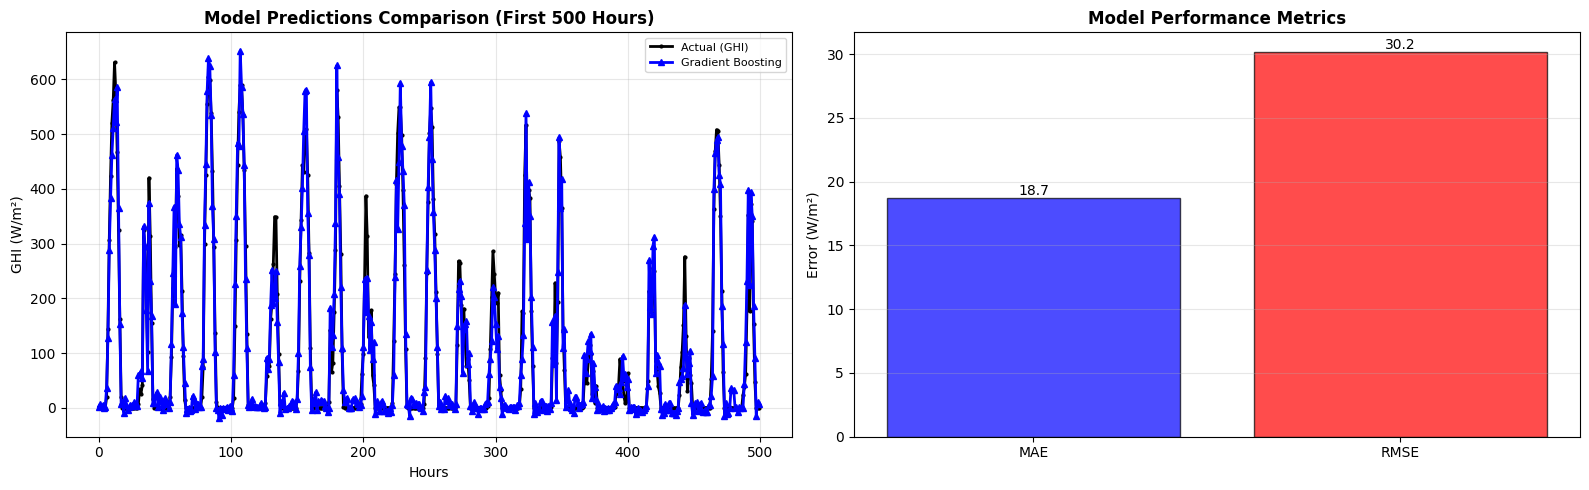

In [7]:
print("\nGenerating visualizations...")

# Plot predictions comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First 500 hours for clarity
n_plot = min(500, len(y_test))
hours = range(n_plot)

# Subplot 1: Predictions
ax = axes[0]
ax.plot(hours, y_test.values[:n_plot], 'o-', label='Actual (GHI)', linewidth=2, markersize=2, color='black')
ax.plot(hours, pred_gb[:n_plot], '^-', label='Gradient Boosting', linewidth=2, markersize=4, color='blue')
ax.set_xlabel('Hours'); ax.set_ylabel('GHI (W/m²)')
ax.set_title('Model Predictions Comparison (First 500 Hours)', fontweight='bold')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

# Subplot 2: Metrics
ax = axes[1]
ax.bar(['MAE', 'RMSE'], [mae_gb, rmse_gb], color=['blue', 'red'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Error (W/m²)')
ax.set_title('Model Performance Metrics', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(ax.patches, [mae_gb, rmse_gb]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('gradient_boosting_forecast.png', dpi=300, bbox_inches='tight')
print("✓ Saved: gradient_boosting_forecast.png")
plt.show()

## 8. Summary

In [8]:
print("="*50)
print("GRADIENT BOOSTING FORECAST SUMMARY")
print("="*50)

print(f"\n1. MODEL PERFORMANCE:")
print(f"   MAE: {mae_gb:.2f} W/m²")
print(f"   RMSE: {rmse_gb:.2f} W/m²")
print(f"   MAPE (daylight): {mape_gb:.2f}%")

print(f"\n2. FEATURE ENGINEERING:")
print(f"   ✓ Lag features: {len(lags)} lags (1-168 hours)")
print(f"   ✓ Rolling statistics: {len(rolling_windows)} windows")
print(f"   ✓ Cyclical encoding: hour, month, day-of-year")
print(f"   ✓ Rate of change: 1h and 24h differences")
print(f"   ✓ PCA: {n_components} components ({cumulative_variance[-1]:.1%} variance explained)")

print(f"\n3. DATA SPLITS:")
print(f"   ✓ Train: {len(train_df):,} hours")
print(f"   ✓ Test: {len(test_df):,} hours (3 months)")
print(f"   ✓ Temporal ordering preserved")

print(f"\n4. POTENTIAL IMPROVEMENTS:")
print(f"   → Hyperparameter tuning")
print(f"   → Feature selection")
print(f"   → Cross-validation")
print(f"   → Ensemble methods")

print(f"\n" + "="*50)

GRADIENT BOOSTING FORECAST SUMMARY

1. MODEL PERFORMANCE:
   MAE: 18.74 W/m²
   RMSE: 30.20 W/m²
   MAPE (daylight): 44.40%

2. FEATURE ENGINEERING:
   ✓ Lag features: 9 lags (1-168 hours)
   ✓ Rolling statistics: 4 windows
   ✓ Cyclical encoding: hour, month, day-of-year
   ✓ Rate of change: 1h and 24h differences
   ✓ PCA: 30 components (100.0% variance explained)

3. DATA SPLITS:
   ✓ Train: 242,952 hours
   ✓ Test: 2,160 hours (3 months)
   ✓ Temporal ordering preserved

4. POTENTIAL IMPROVEMENTS:
   → Hyperparameter tuning
   → Feature selection
   → Cross-validation
   → Ensemble methods



## 9. Save Forecasts

In [9]:
# Save forecasts to parquet
print('Saving forecasts to parquet...')
try:
    forecast_df = pd.DataFrame({
        'date': test_df.index,
        'forecasted_ghi': pred_gb
    })
    forecast_df.to_parquet('gradient_boosting_forecasts.parquet', index=False)
    print('✓ Saved: gradient_boosting_forecasts.parquet (', len(forecast_df), 'rows)')
except Exception as e:
    print('ERROR writing parquet:', e)

Saving forecasts to parquet...
✓ Saved: gradient_boosting_forecasts.parquet ( 2160 rows)
